# 07 - Results Interpretation

**Purpose:** consolidate the final results around the project question:

> Can time-series history, social-network exposure, review-language signals, and stronger scikit-learn model families help forecast short-term shifts in community attention toward local Yelp businesses?

This interpretation uses the corrected forecasting cohort: **876 businesses** and **68,249 business-month rows** from the 2015-2021 modeling window, excluding rows before each business's first observed modeling-window review.

In [1]:
# Load final metrics, predictions, summaries, and lookup tables for interpretation.
from pathlib import Path
import json

import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

METRICS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_metrics.csv"
PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "forecasting_predictions.csv"
PULSE_METRICS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_metrics.csv"
PULSE_PREDICTIONS_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_predictions.csv"
PULSE_TOPK_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_topk_metrics.csv"
PULSE_CALIBRATION_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_calibration.csv"
GRAPH_SUMMARY_PATH = PROCESSED_DIR / "social_graph_summary.json"
FEATURE_SUMMARY_PATH = PROCESSED_DIR / "forecasting_feature_summary.json"
FORECASTING_DATASET_PATH = PROCESSED_DIR / "forecasting_dataset.csv"
COHORT_BUSINESSES_PATH = PROCESSED_DIR / "forecasting_cohort_businesses.csv"
PULSE_PREDECESSOR_OUTPUT_PATH = OUTPUTS_DIR / "pulse_predecessor_analysis.csv"
CASE_STUDIES_OUTPUT_PATH = OUTPUTS_DIR / "attention_pulse_case_studies.csv"

metrics = pd.read_csv(METRICS_OUTPUT_PATH)
predictions = pd.read_csv(PREDICTIONS_OUTPUT_PATH)
pulse_metrics = pd.read_csv(PULSE_METRICS_OUTPUT_PATH)
pulse_predictions = pd.read_csv(PULSE_PREDICTIONS_OUTPUT_PATH)
pulse_topk_metrics = pd.read_csv(PULSE_TOPK_OUTPUT_PATH)
pulse_calibration = pd.read_csv(PULSE_CALIBRATION_OUTPUT_PATH)
modeling = pd.read_csv(FORECASTING_DATASET_PATH)
business_lookup = pd.read_csv(COHORT_BUSINESSES_PATH)[["business_id", "name", "categories"]]
with GRAPH_SUMMARY_PATH.open("r", encoding="utf-8") as file:
    graph_summary = json.load(file)
with FEATURE_SUMMARY_PATH.open("r", encoding="utf-8") as file:
    feature_summary = json.load(file)

metrics.sort_values(["split", "WAPE", "MAE"])

,split,task,model,train_period,validation_period,test_period,rows,MAE,RMSE,WAPE,model_family,feature_count
0,normal_pre_covid_test,review_count_regression,ML: HGB all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.302771,3.994785,0.381172,HistGradientBoostingRegressor,100
1,normal_pre_covid_test,review_count_regression,ML: historical + business,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.307396,4.082303,0.381938,RandomForestRegressor,16
2,normal_pre_covid_test,review_count_regression,ML: all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.329777,4.092234,0.385642,RandomForestRegressor,100
3,normal_pre_covid_test,review_count_regression,ML: historical + NLP,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.348451,4.069356,0.388733,RandomForestRegressor,71
4,normal_pre_covid_test,review_count_regression,ML: historical,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.350307,4.073155,0.389041,RandomForestRegressor,10
5,normal_pre_covid_test,review_count_regression,Baseline: rolling 3-month avg,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.356737,3.743842,0.390105,temporal_baseline,0
6,normal_pre_covid_test,review_count_regression,ML: historical + SNA,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.368460,4.044762,0.392045,RandomForestRegressor,33
7,normal_pre_covid_test,review_count_regression,ML: HGB selected top 20,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.377967,4.237640,0.393619,SelectKBest + HistGradientBoostingRegressor,100
8,normal_pre_covid_test,review_count_regression,Baseline: last month,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.702217,4.265553,0.447291,temporal_baseline,0
9,normal_pre_covid_test,review_count_regression,ML: Poisson all modalities,2015-02 to 2017-12,2018-01 to 2018-12,2019-01 to 2019-12,10511,2.794019,7.262857,0.462487,PoissonRegressor,100


## Regression Interpretation

Summarize which model family performs best in the single normal pre-COVID split and whether stronger alternatives improve on the simple temporal baselines. This pass compares Random Forests, HistGradientBoosting, Poisson count models, and selected-feature variants on the full business-month cohort. The scoped Prophet top-10 benchmark is kept out of the cohort-wide ranking.

In [2]:
# Build a compact regression summary by chronological split.
regression_summary_rows = []
for split_name, split_metrics in metrics[metrics["task"].eq("review_count_regression")].groupby("split"):
    ranked = split_metrics.sort_values("WAPE").reset_index(drop=True)
    best = ranked.iloc[0]
    hist = split_metrics[split_metrics["model"] == "ML: historical"].iloc[0]
    business = split_metrics[split_metrics["model"] == "ML: historical + business"].iloc[0]
    sna = split_metrics[split_metrics["model"] == "ML: historical + SNA"].iloc[0]
    nlp = split_metrics[split_metrics["model"] == "ML: historical + NLP"].iloc[0]
    all_modalities = split_metrics[split_metrics["model"] == "ML: all modalities"].iloc[0]
    hgb_all = split_metrics[split_metrics["model"] == "ML: HGB all modalities"].iloc[0]
    poisson_all = split_metrics[split_metrics["model"] == "ML: Poisson all modalities"].iloc[0]
    selected_hgb = split_metrics[split_metrics["model"] == "ML: HGB selected top 20"].iloc[0]
    regression_summary_rows.append({
        "split": split_name,
        "best_model": best["model"],
        "best_family": best["model_family"],
        "best_WAPE": best["WAPE"],
        "historical_WAPE": hist["WAPE"],
        "business_WAPE": business["WAPE"],
        "sna_WAPE": sna["WAPE"],
        "nlp_WAPE": nlp["WAPE"],
        "all_modalities_WAPE": all_modalities["WAPE"],
        "hgb_all_WAPE": hgb_all["WAPE"],
        "poisson_all_WAPE": poisson_all["WAPE"],
        "selected_hgb_WAPE": selected_hgb["WAPE"],
        "best_vs_last_month_relative_change": (best["WAPE"] - split_metrics[split_metrics["model"] == "Baseline: last month"].iloc[0]["WAPE"]) / split_metrics[split_metrics["model"] == "Baseline: last month"].iloc[0]["WAPE"],
        "all_vs_historical_relative_change": (all_modalities["WAPE"] - hist["WAPE"]) / hist["WAPE"],
        "all_vs_business_relative_change": (all_modalities["WAPE"] - business["WAPE"]) / business["WAPE"],
    })
regression_summary = pd.DataFrame(regression_summary_rows)
regression_summary

,split,best_model,best_family,best_WAPE,historical_WAPE,business_WAPE,sna_WAPE,nlp_WAPE,all_modalities_WAPE,hgb_all_WAPE,poisson_all_WAPE,selected_hgb_WAPE,best_vs_last_month_relative_change,all_vs_historical_relative_change,all_vs_business_relative_change
0,normal_pre_covid_test,ML: HGB all modalities,HistGradientBoostingRegressor,0.381172,0.389041,0.381938,0.392045,0.388733,0.385642,0.381172,0.462487,0.393619,-0.147822,-0.008735,0.0097


## Pulse Interpretation

Summarize pulse-classification performance with class balance and probability quality in mind:

- F1 uses a cutoff tuned on the validation period;
- PR-AUC and top-k metrics assess ranking quality for rare pulse events;
- Brier score and calibration bins assess whether pulse probabilities behave like useful risk estimates.

In [3]:
# Build a compact pulse-classification summary by chronological split.
# Pulse summaries emphasize rare-event detection and probability quality rather than overall accuracy.
pulse_summary_rows = []
for split_name, split_metrics in pulse_metrics.groupby("split"):
    ranked = split_metrics.sort_values(["F1", "PR_AUC"], ascending=[False, False]).reset_index(drop=True)
    best = ranked.iloc[0]
    hist = split_metrics[split_metrics["model"] == "ML: historical"].iloc[0]
    business = split_metrics[split_metrics["model"] == "ML: historical + business"].iloc[0]
    sna = split_metrics[split_metrics["model"] == "ML: historical + SNA"].iloc[0]
    nlp = split_metrics[split_metrics["model"] == "ML: historical + NLP"].iloc[0]
    all_modalities = split_metrics[split_metrics["model"] == "ML: all modalities"].iloc[0]
    hgb_all = split_metrics[split_metrics["model"] == "ML: HGB all modalities"].iloc[0]
    logistic_all = split_metrics[split_metrics["model"] == "ML: Logistic all modalities"].iloc[0]
    selected_hgb = split_metrics[split_metrics["model"] == "ML: HGB selected top 20"].iloc[0]
    best_brier = split_metrics.sort_values("Brier").iloc[0]

    split_topk_10 = pulse_topk_metrics[
        (pulse_topk_metrics["split"] == split_name)
        & (pulse_topk_metrics["k_fraction"] == 0.10)
    ].copy()
    best_topk_10 = split_topk_10.sort_values(["precision_at_k", "recall_at_k"], ascending=[False, False]).iloc[0]
    all_topk_10 = split_topk_10[split_topk_10["model"] == "ML: all modalities"].iloc[0]

    pulse_summary_rows.append({
        "split": split_name,
        "positive_rate": all_modalities["positive_rate"],
        "best_model": best["model"],
        "best_family": best["model_family"],
        "best_F1": best["F1"],
        "best_PR_AUC": best["PR_AUC"],
        "best_Brier": best["Brier"],
        "best_threshold": best["decision_threshold"],
        "best_validation_F1": best["validation_F1"],
        "best_brier_model": best_brier["model"],
        "best_brier": best_brier["Brier"],
        "historical_F1": hist["F1"],
        "business_F1": business["F1"],
        "sna_F1": sna["F1"],
        "nlp_F1": nlp["F1"],
        "all_modalities_F1": all_modalities["F1"],
        "all_modalities_PR_AUC": all_modalities["PR_AUC"],
        "hgb_all_F1": hgb_all["F1"],
        "hgb_all_PR_AUC": hgb_all["PR_AUC"],
        "logistic_all_F1": logistic_all["F1"],
        "logistic_all_PR_AUC": logistic_all["PR_AUC"],
        "selected_hgb_F1": selected_hgb["F1"],
        "selected_hgb_PR_AUC": selected_hgb["PR_AUC"],
        "selected_hgb_Brier": selected_hgb["Brier"],
        "all_modalities_threshold": all_modalities["decision_threshold"],
        "best_precision_at_10pct_model": best_topk_10["model"],
        "best_precision_at_10pct": best_topk_10["precision_at_k"],
        "best_recall_at_10pct": best_topk_10["recall_at_k"],
        "all_modalities_precision_at_10pct": all_topk_10["precision_at_k"],
        "all_modalities_recall_at_10pct": all_topk_10["recall_at_k"],
    })
pulse_summary = pd.DataFrame(pulse_summary_rows)
pulse_summary

,split,positive_rate,best_model,best_family,best_F1,best_PR_AUC,best_Brier,best_threshold,best_validation_F1,best_brier_model,...,logistic_all_PR_AUC,selected_hgb_F1,selected_hgb_PR_AUC,selected_hgb_Brier,all_modalities_threshold,best_precision_at_10pct_model,best_precision_at_10pct,best_recall_at_10pct,all_modalities_precision_at_10pct,all_modalities_recall_at_10pct
0,normal_pre_covid_test,0.131957,ML: HGB selected top 20,SelectKBest + HistGradientBoostingClassifier,0.30683,0.236361,0.110111,0.165,0.381379,ML: HGB all modalities,...,0.209664,0.30683,0.236361,0.110111,0.405,ML: historical,0.306084,0.232156,0.276616,0.209805


## Final Model Comparison Summary

This table is the report-ready bridge between metrics and interpretation for the normal pre-COVID split. It combines the best full-cohort review-count model, the best attention-pulse model, simple baseline comparisons, and a compact modality takeaway.

In [4]:
# Combine regression, pulse, baseline, and modality comparisons into one final table.
comparison_rows = []
for split_name in regression_summary["split"]:
    split_regression = metrics[(metrics["split"] == split_name) & metrics["task"].eq("review_count_regression")].copy()
    split_pulse = pulse_metrics[pulse_metrics["split"] == split_name].copy()
    reg = regression_summary[regression_summary["split"] == split_name].iloc[0]
    pulse = pulse_summary[pulse_summary["split"] == split_name].iloc[0]

    last_month = split_regression[split_regression["model"] == "Baseline: last month"].iloc[0]
    best_pulse_baseline = (
        split_pulse[split_pulse["model_family"] == "rule_baseline"]
        .sort_values(["F1", "PR_AUC"], ascending=[False, False])
        .iloc[0]
    )

    sna_wape_change = (reg["sna_WAPE"] - reg["historical_WAPE"]) / reg["historical_WAPE"]
    nlp_wape_change = (reg["nlp_WAPE"] - reg["historical_WAPE"]) / reg["historical_WAPE"]
    pulse_sna_f1_change = pulse["sna_F1"] - pulse["historical_F1"]
    pulse_nlp_f1_change = pulse["nlp_F1"] - pulse["historical_F1"]

    modality_takeaway = "Normal pre-COVID patterns are learnable, but count-model gains over strong temporal/business baselines are modest; selected HGB gives the cleanest pulse F1, while top-k pulse ranking remains competitive with simpler historical/RF models."

    comparison_rows.append({
        "split": split_name,
        "best_review_count_model": reg["best_model"],
        "best_review_count_WAPE": reg["best_WAPE"],
        "last_month_baseline_WAPE": last_month["WAPE"],
        "best_count_vs_last_month_pct": reg["best_vs_last_month_relative_change"] * 100,
        "best_pulse_model": pulse["best_model"],
        "best_pulse_F1": pulse["best_F1"],
        "best_pulse_PR_AUC": pulse["best_PR_AUC"],
        "best_pulse_baseline": best_pulse_baseline["model"],
        "best_pulse_baseline_F1": best_pulse_baseline["F1"],
        "best_pulse_vs_baseline_F1_delta": pulse["best_F1"] - best_pulse_baseline["F1"],
        "best_top10_precision_model": pulse["best_precision_at_10pct_model"],
        "best_top10_precision": pulse["best_precision_at_10pct"],
        "sna_vs_historical_WAPE_pct": sna_wape_change * 100,
        "nlp_vs_historical_WAPE_pct": nlp_wape_change * 100,
        "pulse_sna_vs_historical_F1_delta": pulse_sna_f1_change,
        "pulse_nlp_vs_historical_F1_delta": pulse_nlp_f1_change,
        "modality_takeaway": modality_takeaway,
    })

model_comparison_summary = pd.DataFrame(comparison_rows)
MODEL_COMPARISON_SUMMARY_PATH = OUTPUTS_DIR / "model_comparison_summary.csv"
model_comparison_summary.to_csv(MODEL_COMPARISON_SUMMARY_PATH, index=False)
model_comparison_summary

,split,best_review_count_model,best_review_count_WAPE,last_month_baseline_WAPE,best_count_vs_last_month_pct,best_pulse_model,best_pulse_F1,best_pulse_PR_AUC,best_pulse_baseline,best_pulse_baseline_F1,best_pulse_vs_baseline_F1_delta,best_top10_precision_model,best_top10_precision,sna_vs_historical_WAPE_pct,nlp_vs_historical_WAPE_pct,pulse_sna_vs_historical_F1_delta,pulse_nlp_vs_historical_F1_delta,modality_takeaway
0,normal_pre_covid_test,ML: HGB all modalities,0.381172,0.447291,-14.782154,ML: HGB selected top 20,0.30683,0.236361,Baseline: rising recent activity,0.215558,0.091271,ML: historical,0.306084,0.772386,-0.078958,0.003601,-0.003328,"Normal pre-COVID patterns are learnable, but c..."


## Random Forest Feature Importance

The cells below inspect the all-modality Random Forest models used for the review-count and attention-pulse tasks. They reuse `rf_model`, `rf_clf`, `feature_cols`, and the normal pre-COVID train/test split when those objects already exist; when the notebook is run from a clean kernel, they rebuild the same split and fit equivalent Random Forest models so the interpretation is reproducible.

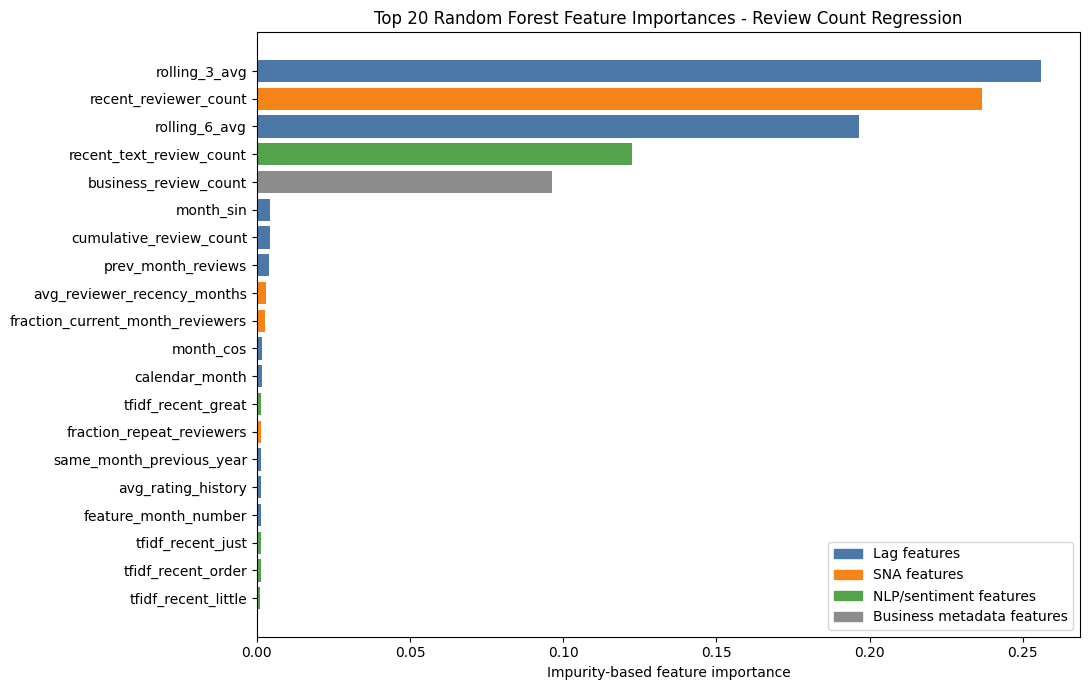

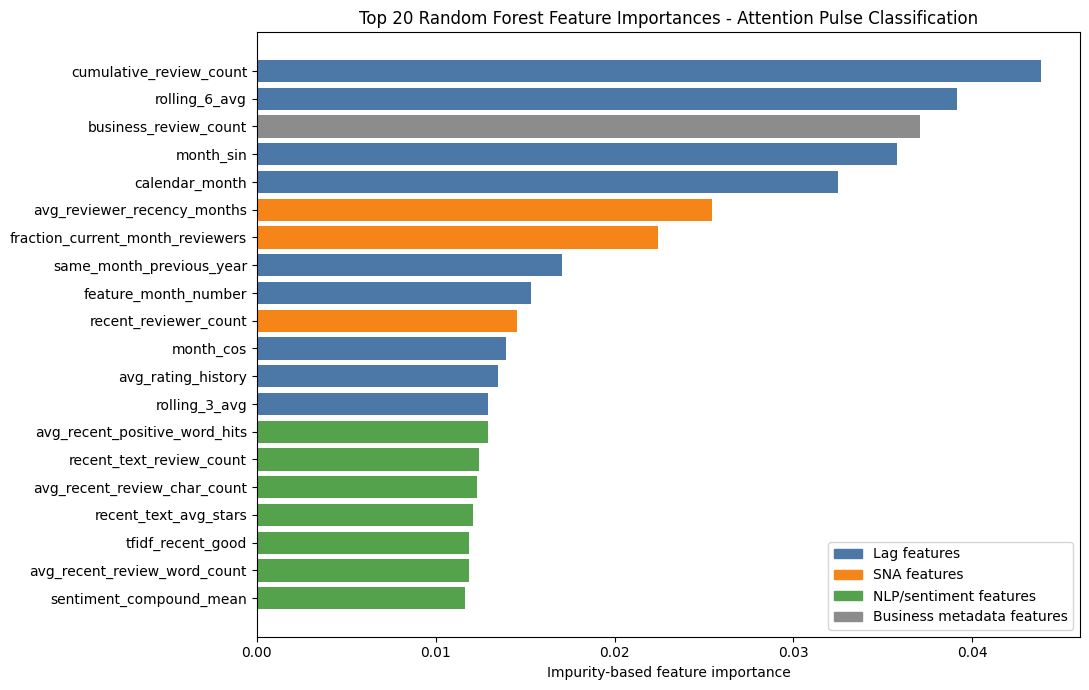

c:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\feature_importance_regression.png
c:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\models\feature_importance_pulse.png


,feature,importance,feature_type,model,impurity_rank
0,rolling_3_avg,0.255856,Lag features,Review-count Random Forest,1
1,recent_reviewer_count,0.236717,SNA features,Review-count Random Forest,2
2,rolling_6_avg,0.196677,Lag features,Review-count Random Forest,3
3,recent_text_review_count,0.122317,NLP/sentiment features,Review-count Random Forest,4
4,business_review_count,0.096302,Business metadata features,Review-count Random Forest,5
5,month_sin,0.004310,Lag features,Review-count Random Forest,6
6,cumulative_review_count,0.004191,Lag features,Review-count Random Forest,7
7,prev_month_reviews,0.004082,Lag features,Review-count Random Forest,8
8,avg_reviewer_recency_months,0.003148,SNA features,Review-count Random Forest,9
9,fraction_current_month_reviewers,0.002813,SNA features,Review-count Random Forest,10


In [5]:
# Extract and plot top Random Forest feature importances for regression and pulse detection.
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

import matplotlib
IN_NOTEBOOK = "get_ipython" in globals()
if not IN_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

FIGURES_DIR = OUTPUTS_DIR / "figures" / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

historical_features = [
    "prev_month_reviews",
    "rolling_3_avg",
    "rolling_6_avg",
    "same_month_previous_year",
    "cumulative_review_count",
    "avg_rating_history",
    "calendar_month",
    "month_sin",
    "month_cos",
    "feature_month_number",
]
business_features = [
    "business_stars",
    "business_review_count",
    "is_restaurant",
    "is_food",
    "is_nightlife",
    "is_tourism",
]
static_sna_features = [
    "recent_reviewer_count",
    "avg_reviewer_degree",
    "avg_reviewer_weighted_degree",
    "max_reviewer_pagerank",
    "max_reviewer_weighted_pagerank",
    "avg_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_pagerank",
    "sum_reviewer_weighted_degree",
    "avg_reviewer_friend_shared_businesses",
    "avg_reviewer_friend_category_overlap",
    "fraction_connected_reviewers",
    "fraction_weighted_connected_reviewers",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
]
dynamic_social_exposure_features = [
    "fraction_active_to_date_reviewers",
    "avg_reviewer_reviews_to_date",
    "max_reviewer_reviews_to_date",
    "avg_reviewer_active_months_to_date",
    "fraction_largest_component_reviewers",
    "fraction_high_weighted_pagerank_reviewers",
    "fraction_high_weighted_degree_reviewers",
    "avg_reviewer_recency_months",
    "fraction_current_month_reviewers",
]
sna_features = static_sna_features + dynamic_social_exposure_features
nlp_features = [
    "recent_text_review_count",
    "avg_recent_review_char_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "avg_recent_positive_word_hits",
    "avg_recent_negative_word_hits",
    "recent_text_avg_stars",
    "sentiment_compound_mean",
    "sentiment_positive_pct",
    "sentiment_negative_pct",
] + sorted([column for column in modeling.columns if column.startswith("tfidf_recent_")])

if "feature_cols" not in globals():
    feature_cols = historical_features + business_features + sna_features + nlp_features
feature_cols = list(feature_cols)

missing_feature_cols = [column for column in feature_cols if column not in modeling.columns]
if missing_feature_cols:
    raise ValueError(f"Missing feature columns: {missing_feature_cols}")

SPLIT_NAME = "normal_pre_covid_test"
if "splits" in globals() and SPLIT_NAME in splits:
    feature_importance_split = splits[SPLIT_NAME]
else:
    feature_importance_split = {
        "train_start": "2015-02",
        "train_end": "2017-12",
        "validation_start": "2018-01",
        "validation_end": "2018-12",
        "test_start": "2019-01",
        "test_end": "2019-12",
    }

if "split_modeling_data" in globals():
    train_df, validation_df, test_df = split_modeling_data(feature_importance_split)
else:
    train_mask = (
        (modeling["target_month_str"] >= feature_importance_split["train_start"])
        & (modeling["target_month_str"] <= feature_importance_split["train_end"])
    )
    validation_mask = (
        (modeling["target_month_str"] >= feature_importance_split["validation_start"])
        & (modeling["target_month_str"] <= feature_importance_split["validation_end"])
    )
    test_mask = (
        (modeling["target_month_str"] >= feature_importance_split["test_start"])
        & (modeling["target_month_str"] <= feature_importance_split["test_end"])
    )
    train_df = modeling[train_mask].copy()
    validation_df = modeling[validation_mask].copy()
    test_df = modeling[test_mask].copy()

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train_regression = train_df["target_next_month_reviews"].astype(float)
y_test_regression = test_df["target_next_month_reviews"].astype(float)
y_train_pulse = train_df["attention_pulse"].astype(int)
y_test_pulse = test_df["attention_pulse"].astype(int)

if "rf_model" not in globals():
    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )
    rf_model.fit(X_train, y_train_regression)

if "rf_clf" not in globals():
    rf_clf = RandomForestClassifier(
        n_estimators=140,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    rf_clf.fit(X_train, y_train_pulse)

feature_type_lookup = {}
for feature in historical_features:
    feature_type_lookup[feature] = "Lag features"
for feature in sna_features:
    feature_type_lookup[feature] = "SNA features"
for feature in nlp_features:
    feature_type_lookup[feature] = "NLP/sentiment features"
for feature in business_features:
    feature_type_lookup[feature] = "Business metadata features"

feature_type_colors = {
    "Lag features": "#4C78A8",
    "SNA features": "#F58518",
    "NLP/sentiment features": "#54A24B",
    "Business metadata features": "#8C8C8C",
}


def build_importance_frame(model, model_label):
    if len(model.feature_importances_) != len(feature_cols):
        raise ValueError(
            f"{model_label} has {len(model.feature_importances_)} importances, "
            f"but feature_cols has {len(feature_cols)} columns."
        )
    frame = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_,
    })
    frame["feature_type"] = frame["feature"].map(feature_type_lookup).fillna("Business metadata features")
    frame["model"] = model_label
    frame["impurity_rank"] = frame["importance"].rank(method="first", ascending=False).astype(int)
    return frame.sort_values("importance", ascending=False).reset_index(drop=True)


def plot_top_importances(importance_frame, title, output_path):
    top_features = importance_frame.head(20).sort_values("importance", ascending=True)
    colors = top_features["feature_type"].map(feature_type_colors)
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(top_features["feature"], top_features["importance"], color=colors)
    ax.set_title(title)
    ax.set_xlabel("Impurity-based feature importance")
    ax.set_ylabel("")
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color, label=label)
        for label, color in feature_type_colors.items()
    ]
    ax.legend(handles=legend_handles, loc="lower right", frameon=True)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)


regression_importance = build_importance_frame(rf_model, "Review-count Random Forest")
pulse_importance = build_importance_frame(rf_clf, "Pulse Random Forest")

REGRESSION_IMPORTANCE_PATH = FIGURES_DIR / "feature_importance_regression.png"
PULSE_IMPORTANCE_PATH = FIGURES_DIR / "feature_importance_pulse.png"
plot_top_importances(
    regression_importance,
    "Top 20 Random Forest Feature Importances - Review Count Regression",
    REGRESSION_IMPORTANCE_PATH,
)
plot_top_importances(
    pulse_importance,
    "Top 20 Random Forest Feature Importances - Attention Pulse Classification",
    PULSE_IMPORTANCE_PATH,
)

print(REGRESSION_IMPORTANCE_PATH)
print(PULSE_IMPORTANCE_PATH)
pd.concat([regression_importance.head(20), pulse_importance.head(20)], ignore_index=True)


### Interpreting the Top Features

For the review-count regressor, the top five features are `rolling_3_avg`, `recent_reviewer_count`, `rolling_6_avg`, `recent_text_review_count`, and `business_review_count`. This makes intuitive sense: next-month review volume is anchored by recent momentum, the breadth of the recent reviewer base, recent text-bearing review activity, and the business's longer-run popularity. The SNA signal `recent_reviewer_count` being near the top is especially useful because it suggests the model is not only learning how many reviews arrived recently, but also how many distinct people were actively participating around the business.

For the attention-pulse classifier, the top five features are `cumulative_review_count`, `month_sin`, `rolling_6_avg`, `business_review_count`, and `calendar_month`. These point to scale, seasonality, and the business's normal review baseline. That is also plausible for pulse detection: unusual attention is easier to identify once the model knows whether a business is generally high-volume, what its recent baseline looks like, and where the target month falls in New Orleans' seasonal/tourism cycle.

In [6]:
# Compare impurity-based Random Forest importances with permutation importance on the regression test set.
permutation_result = permutation_importance(
    rf_model,
    X_test,
    y_test_regression,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "permutation_importance_mean": permutation_result.importances_mean,
    "permutation_importance_std": permutation_result.importances_std,
})
permutation_importance_df["permutation_rank"] = (
    permutation_importance_df["permutation_importance_mean"]
    .rank(method="first", ascending=False)
    .astype(int)
)

importance_comparison = regression_importance.merge(permutation_importance_df, on="feature", how="left")
importance_comparison["rank_delta_permutation_minus_impurity"] = (
    importance_comparison["permutation_rank"] - importance_comparison["impurity_rank"]
)
importance_comparison = importance_comparison.sort_values("permutation_rank").reset_index(drop=True)
importance_comparison[[
    "feature",
    "feature_type",
    "importance",
    "impurity_rank",
    "permutation_importance_mean",
    "permutation_importance_std",
    "permutation_rank",
    "rank_delta_permutation_minus_impurity",
]].head(20)


,feature,feature_type,importance,impurity_rank,permutation_importance_mean,permutation_importance_std,permutation_rank,rank_delta_permutation_minus_impurity
0,recent_reviewer_count,SNA features,0.236717,2,0.175278,0.002660,1,-1
1,rolling_3_avg,Lag features,0.255856,1,0.141424,0.002854,2,1
2,rolling_6_avg,Lag features,0.196677,3,0.122808,0.001273,3,0
3,business_review_count,Business metadata features,0.096302,5,0.067692,0.001402,4,-1
4,recent_text_review_count,NLP/sentiment features,0.122317,4,0.053400,0.001101,5,1
5,month_sin,Lag features,0.004310,6,0.004131,0.000306,6,0
6,prev_month_reviews,Lag features,0.004082,8,0.003665,0.000391,7,-1
7,cumulative_review_count,Lag features,0.004191,7,0.002189,0.000059,8,1
8,avg_reviewer_recency_months,SNA features,0.003148,9,0.002177,0.000380,9,0
9,calendar_month,Lag features,0.001698,12,0.001249,0.000244,10,-2


### Permutation Importance Check

Permutation importance on the regression test set broadly agrees with the impurity ranking: the same five variables dominate, with only a small order change. `recent_reviewer_count` moves from impurity rank 2 to permutation rank 1, while `rolling_3_avg` moves from impurity rank 1 to permutation rank 2; `rolling_6_avg` remains rank 3. This reinforces the interpretation that recent review momentum and the size of the recent reviewer pool are the strongest signals for next-month activity.

The main discrepancies are lower in the ranking. `business_review_count` rises ahead of `recent_text_review_count` under permutation importance, suggesting long-run popularity contributes more to held-out predictive performance than the impurity split score alone implies. `fraction_current_month_reviewers` appears in the impurity top 10 but falls outside the permutation top 20, which is a useful warning that impurity-based Random Forest importances can overstate correlated or high-split-opportunity features. Overall, the model story is stable: recent activity, reviewer breadth, and business scale matter most.

## What Precedes An Attention Pulse?

This comparison checks whether pulse rows have different recent conditions than non-pulse rows before the target month arrives. It focuses on interpretable signals: review momentum, recent text volume/language, reviewer centrality, and social exposure.


In [7]:
# Print concise text summaries for the report narrative.
pre_pulse_features = [
    "prev_month_reviews",
    "rolling_3_avg",
    "rolling_6_avg",
    "same_month_previous_year",
    "recent_text_review_count",
    "avg_recent_review_word_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "recent_text_avg_stars",
    "sentiment_compound_mean",
    "sentiment_positive_pct",
    "sentiment_negative_pct",
    "recent_reviewer_count",
    "avg_reviewer_weighted_degree",
    "max_reviewer_weighted_pagerank",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
    "fraction_active_to_date_reviewers",
    "avg_reviewer_recency_months",
] + sorted([column for column in modeling.columns if column.startswith("tfidf_recent_")])[:20]

available_pre_pulse_features = [feature for feature in pre_pulse_features if feature in modeling.columns]
# Compare feature averages to identify conditions that tend to precede pulses.
pulse_predecessor_summary = (
    modeling.groupby("attention_pulse")[available_pre_pulse_features]
    .mean()
    .T
    .rename(columns={0: "non_pulse_mean", 1: "pulse_mean"})
)
pulse_predecessor_summary["absolute_difference"] = pulse_predecessor_summary["pulse_mean"] - pulse_predecessor_summary["non_pulse_mean"]
pulse_predecessor_summary["relative_lift_vs_non_pulse"] = pulse_predecessor_summary["pulse_mean"] / pulse_predecessor_summary["non_pulse_mean"].replace(0, np.nan)
pulse_predecessor_summary = pulse_predecessor_summary.sort_values("absolute_difference", ascending=False)
pulse_predecessor_summary_output = pulse_predecessor_summary.reset_index().rename(columns={"index": "feature"})
pulse_predecessor_summary_output.to_csv(PULSE_PREDECESSOR_OUTPUT_PATH, index=False)
pulse_predecessor_summary_output.head(20)

attention_pulse,feature,non_pulse_mean,pulse_mean,absolute_difference,relative_lift_vs_non_pulse
0,sentiment_positive_pct,70.660392,80.419926,9.759534,1.138119
1,avg_recent_review_word_count,87.215370,94.201212,6.985842,1.080099
2,avg_reviewer_weighted_degree,10.778099,12.704430,1.926331,1.178726
3,sentiment_negative_pct,9.219162,10.181082,0.961920,1.104339
4,recent_text_avg_stars,3.655975,3.937210,0.281235,1.076925
5,prev_month_reviews,5.010349,5.145895,0.135546,1.027053
6,reviewer_community_diversity,1.177262,1.266801,0.089539,1.076057
7,sentiment_compound_mean,0.556517,0.638881,0.082364,1.147999
8,share_recent_positive_language,0.721067,0.779101,0.058034,1.080483
9,tfidf_recent_amazing,0.227545,0.254093,0.026548,1.116670


## Example Pulse Case Studies

The table below selects a few high-signal business-months from the normal pre-COVID 2019 test split. It includes correct and incorrect pulse predictions so the report can discuss what the model sees, where it succeeds, and where community attention remains hard to anticipate.

In [8]:
# Compare feature means before pulse vs non-pulse outcomes.
case_model = "ML: HGB selected top 20"
case_split = "normal_pre_covid_test"
case_pool = pulse_predictions[
    (pulse_predictions["split"] == case_split)
    & (pulse_predictions["model"] == case_model)
].copy()
if case_pool.empty:
    case_model = "ML: all modalities"
    case_pool = pulse_predictions[
        (pulse_predictions["split"] == case_split)
        & (pulse_predictions["model"] == case_model)
    ].copy()

# Label prediction outcomes so the case studies include successes and errors.
case_pool["case_type"] = np.select(
    [
        case_pool["attention_pulse"].eq(1) & case_pool["prediction"].eq(1),
        case_pool["attention_pulse"].eq(1) & case_pool["prediction"].eq(0),
        case_pool["attention_pulse"].eq(0) & case_pool["prediction"].eq(1),
        case_pool["attention_pulse"].eq(0) & case_pool["prediction"].eq(0),
    ],
    ["true_positive_pulse", "missed_pulse", "false_alarm", "true_negative"],
    default="other",
)

case_specs = [
    ("true_positive_pulse", False),
    ("missed_pulse", False),
    ("false_alarm", False),
    ("true_positive_pulse", True),
    ("missed_pulse", True),
]
case_frames = []
used_index = set()
for case_type, ascending_probability in case_specs:
    candidates = case_pool[case_pool["case_type"] == case_type].copy()
    if candidates.empty:
        continue
    candidates = candidates.sort_values(
        ["probability", "target_next_month_reviews"],
        ascending=[ascending_probability, False],
    )
    for idx, row in candidates.iterrows():
        if idx not in used_index:
            used_index.add(idx)
            case_frames.append(row.to_frame().T)
            break

case_studies = pd.concat(case_frames, ignore_index=True) if case_frames else case_pool.head(5)
case_studies = (
    case_studies
    .merge(business_lookup, on="business_id", how="left")
    .merge(
        modeling[[
            "business_id",
            "feature_month_str",
            "rolling_3_avg",
            "rolling_6_avg",
            "recent_text_review_count",
            "share_recent_positive_language",
            "share_recent_negative_language",
            "sentiment_compound_mean",
            "sentiment_positive_pct",
            "sentiment_negative_pct",
            "recent_reviewer_count",
            "avg_reviewer_weighted_degree",
            "max_reviewer_weighted_pagerank",
            "fraction_repeat_reviewers",
            "reviewer_community_diversity",
        ]],
        on=["business_id", "feature_month_str"],
        how="left",
    )
)

case_studies["interpretation_note"] = np.select(
    [
        case_studies["case_type"].eq("true_positive_pulse"),
        case_studies["case_type"].eq("missed_pulse"),
        case_studies["case_type"].eq("false_alarm"),
    ],
    [
        "Model correctly flagged a future pulse; inspect recent momentum, reviewers, and language as plausible warning signals.",
        "A pulse occurred despite a low model decision; useful for discussing hidden offline events or weak digital precursors.",
        "Model expected a pulse that did not materialize; useful for discussing noisy attention signals and threshold trade-offs.",
    ],
    default="Stable non-pulse example.",
)

case_columns = [
    "case_type",
    "model",
    "business_id",
    "name",
    "target_month_str",
    "attention_pulse",
    "prediction",
    "probability",
    "decision_threshold",
    "target_next_month_reviews",
    "pulse_baseline_reviews",
    "pulse_relative_lift",
    "rolling_3_avg",
    "rolling_6_avg",
    "recent_text_review_count",
    "share_recent_positive_language",
    "share_recent_negative_language",
    "sentiment_compound_mean",
    "sentiment_positive_pct",
    "sentiment_negative_pct",
    "recent_reviewer_count",
    "avg_reviewer_weighted_degree",
    "max_reviewer_weighted_pagerank",
    "fraction_repeat_reviewers",
    "reviewer_community_diversity",
    "interpretation_note",
]
case_studies = case_studies[case_columns]
case_studies.to_csv(CASE_STUDIES_OUTPUT_PATH, index=False)
case_studies

,case_type,model,business_id,name,target_month_str,attention_pulse,prediction,probability,decision_threshold,target_next_month_reviews,...,share_recent_negative_language,sentiment_compound_mean,sentiment_positive_pct,sentiment_negative_pct,recent_reviewer_count,avg_reviewer_weighted_degree,max_reviewer_weighted_pagerank,fraction_repeat_reviewers,reviewer_community_diversity,interpretation_note
0,true_positive_pulse,ML: HGB selected top 20,5xRmemqmR89BpGoOA25hqA,Dian Xin,2019-03,1,1,0.929651,0.165,15.0,...,0.208333,0.812417,95.652174,4.347826,24.0,25.972002,0.001942,0.666667,4.0,Model correctly flagged a future pulse; inspec...
1,missed_pulse,ML: HGB selected top 20,rOsC1rDpIxvNoHxEvNFjeA,Backspace Bar & Kitchen,2019-12,1,0,0.164962,0.165,7.0,...,0.071429,0.923667,100.000000,0.000000,14.0,1.894974,0.000256,0.857143,1.0,A pulse occurred despite a low model decision;...
2,false_alarm,ML: HGB selected top 20,t1qF12NdW8KvCqxqbvy-Hg,Cafe Envie & Espresso Bar,2019-04,0,1,0.753972,0.165,0.0,...,0.000000,0.041400,50.000000,50.000000,3.0,0.897950,0.000060,0.666667,1.0,Model expected a pulse that did not materializ...
3,true_positive_pulse,ML: HGB selected top 20,CBGqxzHew6PveH_YdKLYpw,Voodoo Authentica,2019-03,1,1,0.165028,0.165,4.0,...,0.000000,0.941600,100.000000,0.000000,7.0,0.000000,0.000000,0.428571,0.0,Model correctly flagged a future pulse; inspec...
4,missed_pulse,ML: HGB selected top 20,YvrV_Tc9syF2Wch0HOIT3A,Flamingo A-Go-Go,2019-08,1,0,0.012321,0.165,39.0,...,0.341463,0.605332,78.947368,21.052632,81.0,0.000000,0.000000,0.802469,0.0,A pulse occurred despite a low model decision;...


In [9]:
# Print social graph and forecasting dataset metadata for auditability.
print("Social graph summary")
for key, value in graph_summary.items():
    print(f"{key}: {value}")

print("\nForecasting dataset summary")
for key, value in feature_summary.items():
    print(f"{key}: {value}")

Social graph summary
active_review_threshold: 5
edge_weight_formula: 1 + log1p(shared_business_count) + category_jaccard
sna_review_window_start: 2015-02
sna_review_window_end: 2017-12
sna_window_basis: matches 06_forecasting_models target_month_str training split
training_window_reviews: 206862
total_local_reviews_available: 635521
reviewing_users: 92329
matched_user_profiles: 92329
active_users: 8351
graph_nodes: 8351
graph_edges: 23563
mean_edge_weight: 1.7405717853432006
mean_edge_shared_business_count: 1.1472647795272248
mean_edge_category_jaccard: 0.2604275800959453
connected_components: 4254
largest_component_size: 4054
isolated_active_users: 4213
community_method: weighted_louvain_largest_component
communities_assigned: 32
threshold_sensitivity_output: C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\data\processed\new_orleans\active_reviewer_threshold_sensitivity.csv
output: C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\data\processed\new_orleans\use

In [10]:
# Select representative true positive, missed, and false-alarm pulse case studies.
for _, row in regression_summary.iterrows():
    split = row["split"]
    best_vs_last_month = row["best_vs_last_month_relative_change"] * 100
    all_vs_hist = row["all_vs_historical_relative_change"] * 100
    all_vs_business = row["all_vs_business_relative_change"] * 100
    print(f"{split} regression:")
    print(f"  Best model: {row['best_model']} ({row['best_family']}) with WAPE={row['best_WAPE']:.4f}")
    print(f"  Best vs last-month baseline: {best_vs_last_month:+.2f}%")
    print(f"  HGB all modalities WAPE: {row['hgb_all_WAPE']:.4f}")
    print(f"  Poisson all modalities WAPE: {row['poisson_all_WAPE']:.4f}")
    print(f"  Selected HGB WAPE: {row['selected_hgb_WAPE']:.4f}")
    print(f"  All modalities vs historical: {all_vs_hist:+.2f}%")
    print(f"  All modalities vs historical+business: {all_vs_business:+.2f}%")

print()
for _, row in pulse_summary.iterrows():
    split = row["split"]
    print(f"{split} attention pulses:")
    print(f"  Positive rate: {row['positive_rate']:.3f}")
    print(f"  Best thresholded model: {row['best_model']} ({row['best_family']}) with F1={row['best_F1']:.4f}, PR-AUC={row['best_PR_AUC']:.4f}, Brier={row['best_Brier']:.4f}")
    print(f"  Best model threshold: {row['best_threshold']:.3f}; validation F1={row['best_validation_F1']:.4f}")
    print(f"  Best Brier model: {row['best_brier_model']} with Brier={row['best_brier']:.4f}")
    print(f"  HGB selected top 20: F1={row['selected_hgb_F1']:.4f}, PR-AUC={row['selected_hgb_PR_AUC']:.4f}, Brier={row['selected_hgb_Brier']:.4f}")
    print(f"  Logistic all modalities: F1={row['logistic_all_F1']:.4f}, PR-AUC={row['logistic_all_PR_AUC']:.4f}")
    print(f"  Best precision@10%: {row['best_precision_at_10pct_model']} with precision={row['best_precision_at_10pct']:.4f}, recall={row['best_recall_at_10pct']:.4f}")

normal_pre_covid_test regression:
  Best model: ML: HGB all modalities (HistGradientBoostingRegressor) with WAPE=0.3812
  Best vs last-month baseline: -14.78%
  HGB all modalities WAPE: 0.3812
  Poisson all modalities WAPE: 0.4625
  Selected HGB WAPE: 0.3936
  All modalities vs historical: -0.87%
  All modalities vs historical+business: +0.97%

normal_pre_covid_test attention pulses:
  Positive rate: 0.132
  Best thresholded model: ML: HGB selected top 20 (SelectKBest + HistGradientBoostingClassifier) with F1=0.3068, PR-AUC=0.2364, Brier=0.1101
  Best model threshold: 0.165; validation F1=0.3814
  Best Brier model: ML: HGB all modalities with Brier=0.1094
  HGB selected top 20: F1=0.3068, PR-AUC=0.2364, Brier=0.1101
  Logistic all modalities: F1=0.2868, PR-AUC=0.2097
  Best precision@10%: ML: historical with precision=0.3061, recall=0.2322


## Community-Level vs Business-Level Forecasting

Community-level forecasting is more legible, not automatically more accurate. Aggregating reviews by reviewer community smooths much of the business-month noise and makes group rhythms, seasonal movement, and the 2020-2021 break easier to see. The Prophet community models use the same normal pre-COVID holdout as the business-level Prophet benchmark; their MAE values are naturally larger because they forecast aggregate counts, and their relative errors vary by community.

Business-level forecasting is more actionable. A community forecast can say that a reviewer group is becoming more or less active, but it cannot tell a restaurant, bar, tour operator, or analyst which specific business-month is likely to gain attention. The business-level regression and pulse models answer the operational version of the question: where might community attention concentrate next?

For the research question, the two granularities are complementary. Community-level models support the idea that Yelp attention has social-group rhythms, while business-level models test whether those rhythms, recent activity, sentiment, and SNA exposure can be localized into useful forecasts. The practical conclusion is that community-level forecasting is best for context, seasonality, and shock diagnostics, while business-level forecasting is the better unit for targeted interpretation and decision-making.

## Interpretation Structure

1. **Normal-period lens:** the main metrics estimate ordinary 2019 pre-COVID forecasting performance, not robustness to the 2020-2021 disruption.
2. **Count forecasting:** all-modality HGB is the best full-cohort count model, but the margin over historical/business features and the rolling baseline is small, so temporal momentum remains the core signal.
3. **Pulse framing:** pulse prediction better matches the project objective because it asks whether a business is about to receive unusual community attention, not merely whether already-popular businesses keep receiving reviews.
4. **Ranking versus thresholding:** selected HGB gives the best thresholded pulse F1, while top-k metrics show that simpler historical/RF rankings are still competitive for analyst-style candidate retrieval.
5. **Interpretability:** feature importances, pulse predecessor means, and case studies all point to recent momentum, reviewer breadth, business scale, and recent sentiment/language as the clearest signals.
6. **Granularity:** community-level forecasts reveal group rhythms and disruption context; business-level forecasts are the actionable layer for the research question.

## Final Position

This project should be presented as an interpretable multimodal analytics study of **normal pre-COVID local community attention dynamics**, not as a claim that the most complex model always wins.

The strongest academic story is:

- **Normal-period count patterns are learnable, but noisy.** The all-modality HGB regressor wins the 2019 full-cohort test split, with WAPE about 0.381 versus 0.390 for the rolling 3-month baseline.
- **Temporal baselines remain very strong.** For the top-10 business Prophet benchmark, the rolling 3-month average is still the best performer, so recent history should be treated as the anchor rather than a straw baseline.
- **Attention pulses are a better framing for community attention.** Selected HGB improves thresholded pulse F1 over the rule baselines, and top-k metrics show the models can enrich candidate sets above the base pulse rate.
- **SNA and NLP add interpretation more than guaranteed lift.** `recent_reviewer_count` is one of the strongest count-forecast features, and pulse rows show higher VADER positivity/compound sentiment, but SNA/NLP ablation gains are modest.
- **Community-level forecasts add context.** Large reviewer communities have readable aggregate rhythms and visible disruption patterns, while business-level models remain the practical unit for deciding where attention may concentrate.
- **Case studies make the model auditable.** Correct predictions, missed pulses, and false alarms show where digital traces anticipate attention and where Yelp data remains incomplete.

Key limitations:

- Yelp friendship links are static.
- SNA features measure exposure, not causal influence.
- NLP features are lightweight VADER/lexicon/text-length/TF-IDF signals.
- The main evaluation excludes the 2020-2021 disruption, so it should not be read as shock-robust forecasting.
- Prophet results are scoped benchmarks, not full-cohort replacements for the ML comparison.
- Review activity is a proxy for Yelp attention, not revenue or true customer volume.
- Static business metadata may include end-of-dataset information.
- Calibration is diagnostic, not a guarantee that probabilities transfer outside this dataset.